## Script to verify the simulation against anisotropy theory

In [ ]:
import numpy as np
import opmsim as opm
from opmsim.rays import PolarRays
from opmsim.dipole_source import DipoleSource
from opmsim.optical_system import OpticalSystem
from opmsim.optical_elements import SineLens, LinearPolariser, FlatMirror
import opmsim.anisotropy as anisotropy
import matplotlib.pyplot as plt

In [ ]:
# List of NAs to check
NA_list = np.linspace(0.01, 0.99, 5, endpoint=True)

In [ ]:
# Generate optical systems
# Optical system is a simple one lens system
element_lists = [[SineLens(NA=NA_list[i], focal_length=1)] for i in range(len(NA_list))]
element_lists_m = [[SineLens(NA=NA_list[i], focal_length=1), FlatMirror()] for i in range(len(NA_list))]

anisotropy_theory = [anisotropy.theoretical_anisotropy(NA, (np.pi/2, 0)) for NA in NA_list]
print(anisotropy_theory)

# Create dipole sources
source_x = DipoleSource((0,0))  # single x-dipole
source_x.plot_distribution()
source_y = DipoleSource((np.pi/2,0))  # single y-dipole
source_y.plot_distribution()


In [ ]:
anisotropy_theory_x = []
anisotropy_sim_x = []

anisotropy_theory_y = []
anisotropy_sim_y = []

for elements in element_lists:
    os = OpticalSystem(elements=elements, source=source_x)
    os.trace_system()
    print(np.mean(os.get_detector().Ix_integral), np.mean(os.get_detector().Iy_integral))
    aniso_sim = anisotropy.calculate_anisotropy(os.detector, 0)
    aniso_theory = anisotropy.theoretical_anisotropy(NA=elements[0].NA, dipole_orientation=(0,0))
    anisotropy_sim_x.append(aniso_sim)
    anisotropy_theory_x.append(aniso_theory)

    os = OpticalSystem(elements=elements, source=source_y)
    os.trace_system()
    print(np.mean(os.get_detector().Ix_integral), np.mean(os.get_detector().Iy_integral))
    aniso_sim = anisotropy.calculate_anisotropy(os.detector, np.pi/2)
    aniso_theory = anisotropy.theoretical_anisotropy(NA=elements[0].NA, dipole_orientation=(0,0))
    anisotropy_sim_y.append(aniso_sim)
    anisotropy_theory_y.append(aniso_theory)


In [ ]:
print("x anisotropy:", anisotropy_sim_x)
# print(anisotropy_theory_x)
print("y anisotropy:", anisotropy_sim_y)
# print(anisotropy_theory_y)
print("anisotropy_theory", anisotropy_theory)


## Now check the photoselection anisotropy 

In [ ]:
# Create dipole sources
source_uniform = DipoleSource()
source_uniform.generate_dipole_ensemble(dipole_count=500)
source_uniform.classical_photoselection((0,0))  # x excitation

print("NAs", NA_list)

element_lists = [[SineLens(NA=NA_list[i], focal_length=1)] for i in range(len(NA_list))]

anisotropy_photoselection_sim = []
anisotropy_photoselection_theory = [anisotropy.theoretical_anisotropy_population(NA) for NA in NA_list]

print(anisotropy_photoselection_theory)


In [ ]:
for elements in element_lists:
    os = OpticalSystem(elements=elements, source=source_uniform)
    source_uniform.plot_distribution()
    os.default_ray_count = 10_000
    os.trace_system()
    print(os.get_detector().Ix_integral, os.get_detector().Iy_integral)
    anisotropy_photoselection_sim.append(
        anisotropy.calculate_anisotropy(os.get_detector(), 0))
    

In [ ]:
print("anisotropy_photoselection_sim", anisotropy_photoselection_sim)
print("anisotropy_photoselection_theory", anisotropy_photoselection_theory) 

## Now test all angles of single dipoles

In [ ]:
phi_d_angles = np.linspace(0, 2 * np.pi, 10)  # dipole azimuth
alpha_d_angles = np.linspace(0, np.pi/2, 5)  # dipole polar
aniso_grid = np.zeros((len(NA_list), len(phi_d_angles), len(alpha_d_angles)))
aniso_grid_theory = np.zeros((len(NA_list), len(phi_d_angles), len(alpha_d_angles)))
# source_uniform = DipoleSource()
# source_uniform.generate_dipole_ensemble(2500)

print("phis", phi_d_angles)
print("theta", alpha_d_angles)

In [ ]:
for i, NA in enumerate(NA_list):
    for m, theta in enumerate(alpha_d_angles):
        for n, phi in enumerate(phi_d_angles):
            source_a = DipoleSource((phi, theta))
            # source_a.plot_distribution()
            os = OpticalSystem(elements=element_lists_m[i], source=source_a)
            os.ray_generation_method = 'rings'
            os.trace_system(plot_pupil=False)
            print("phi:", phi, "theta", theta)
            aniso_grid[i, n, m] = anisotropy.calculate_anisotropy(os.get_detector(), np.pi/2)
            aniso_grid_theory[i, n, m] = anisotropy.theoretical_anisotropy(NA, (phi, theta))
            

In [ ]:
f = plt.figure(figsize=(13,7))
n_plots = aniso_grid.shape[0]
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

for n in range(aniso_grid.shape[0]):
    row = int(np.ceil(n / n_cols))
    col = (n % n_cols) + 1
    ax = f.add_subplot(n_rows, n_cols, n+1)
    pc = ax.pcolormesh(alpha_d_angles, phi_d_angles, aniso_grid[n, :, :],\
    shading='auto')
    f.colorbar(pc)
    ax.set_title(f"NA: {NA_list[n]}")

f.set_tight_layout(True)
f.suptitle("Simulation")

ft = plt.figure(figsize=(13,7))
for n in range(aniso_grid_theory.shape[0]):
    row = int(np.ceil(n / n_cols))
    col = (n % n_cols) + 1
    ax = ft.add_subplot(n_rows, n_cols, n+1)
    # m = ax.imshow((aniso_grid_theory[n, :, :]))
    pc = ax.pcolormesh(alpha_d_angles, phi_d_angles, aniso_grid_theory[n, :, :],\
        shading='auto')

    ft.colorbar(pc)
    ax.set_title(f"NA: {NA_list[n]}")

ft.set_tight_layout(True)
ft.suptitle("Theory")

In [ ]:
resids = aniso_grid_theory-aniso_grid

# print(resids)
f = plt.figure()
n_plots = resids.shape[0]
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
print("NAs", NA_list)
print(n_rows, n_cols)

xlabs = print("phis", phi_d_angles)
print("theta", alpha_d_angles)

for n in range(resids.shape[0]):
    row = int(np.ceil(n / n_cols))
    col = (n % n_cols) + 1
    ax = f.add_subplot(n_rows, n_cols, n+1)
    pc = ax.pcolormesh(alpha_d_angles, phi_d_angles, resids[n, :, :],\
        shading='auto')    
    f.colorbar(pc)
    ax.set_title(f"NA: {NA_list[n]}")

f.set_tight_layout(True)

## Compare the ring and fibonacci spiral methods

In [ ]:
phi_d_angles = np.linspace(0, 2 * np.pi, 10)  # dipole azimuth
alpha_d_angles = np.linspace(0, np.pi/2, 5)  # dipole polar

aniso_grid = np.zeros((len(NA_list), len(phi_d_angles), len(alpha_d_angles)))
aniso_grid_theory = np.zeros((len(NA_list), len(phi_d_angles), len(alpha_d_angles)))
aniso_grid_rings = np.zeros((len(NA_list), len(phi_d_angles), len(alpha_d_angles)))
aniso_grid_theory_rings = np.zeros((len(NA_list), len(phi_d_angles), len(alpha_d_angles)))

In [ ]:
for i, NA in enumerate(NA_list):
    for m, theta in enumerate(alpha_d_angles):
        for n, phi in enumerate(phi_d_angles):
            print("phi:", phi, "theta", theta)

            # Fibonacci method
            source_a = DipoleSource((phi, theta))
            os = OpticalSystem(elements=element_lists_m[i], source=source_a)
            os.ray_generation_method = 'fibonacci'
            os.trace_system(plot_pupil=False)
            aniso_grid[i, n, m] = anisotropy.calculate_anisotropy(os.get_detector(), np.pi/2)
            aniso_grid_theory[i, n, m] = anisotropy.theoretical_anisotropy(NA, (phi, theta))

            # Concentric rings method
            os = OpticalSystem(elements=element_lists_m[i], source=source_a)
            os.ray_generation_method = 'rings'
            os.trace_system(plot_pupil=False)
            aniso_grid_rings[i, n, m] = anisotropy.calculate_anisotropy(os.get_detector(), np.pi/2)
            aniso_grid_theory_rings[i, n, m] = anisotropy.theoretical_anisotropy(NA, (phi, theta))

NAs [0.01  0.255 0.5   0.745 0.99 ]
2 3
phis [0.         0.6981317  1.3962634  2.0943951  2.7925268  3.4906585
 4.1887902  4.88692191 5.58505361 6.28318531]
theta [0.         0.39269908 0.78539816 1.17809725 1.57079633]
NAs [0.01  0.255 0.5   0.745 0.99 ]
2 3
phis [0.         0.6981317  1.3962634  2.0943951  2.7925268  3.4906585
 4.1887902  4.88692191 5.58505361 6.28318531]
theta [0.         0.39269908 0.78539816 1.17809725 1.57079633]


Text(0.5, 0.98, 'Anisotropy residuals (ring method)')

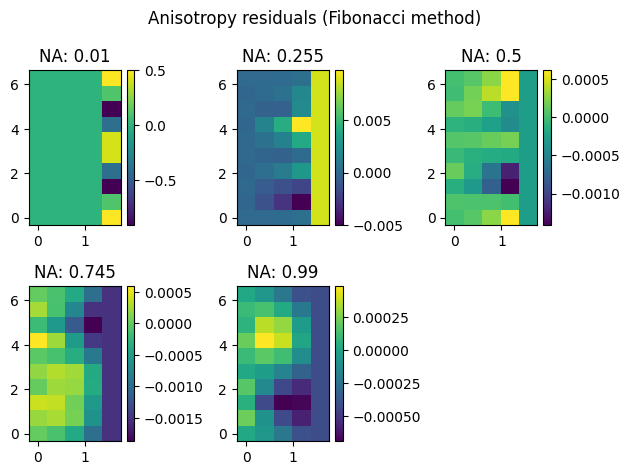

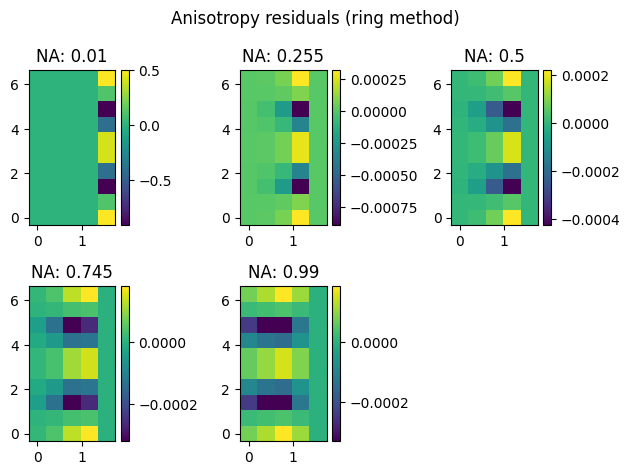

In [9]:
resids = aniso_grid_theory-aniso_grid

# print(resids)
f = plt.figure()
n_plots = resids.shape[0]
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
print("NAs", NA_list)
print(n_rows, n_cols)

xlabs = print("phis", phi_d_angles)
print("theta", alpha_d_angles)

for n in range(resids.shape[0]):
    row = int(np.ceil(n / n_cols))
    col = (n % n_cols) + 1
    ax = f.add_subplot(n_rows, n_cols, n+1)
    pc = ax.pcolormesh(alpha_d_angles, phi_d_angles, resids[n, :, :],\
        shading='auto')    
    f.colorbar(pc)
    ax.set_title(f"NA: {NA_list[n]}")

f.set_tight_layout(True)
f.suptitle("Anisotropy residuals (Fibonacci method)")

resids_rings = aniso_grid_theory_rings-aniso_grid_rings

# print(resids)
f_rings = plt.figure()
n_plots = resids.shape[0]
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
print("NAs", NA_list)
print(n_rows, n_cols)

xlabs = print("phis", phi_d_angles)
print("theta", alpha_d_angles)

for n in range(resids.shape[0]):
    row = int(np.ceil(n / n_cols))
    col = (n % n_cols) + 1
    ax_rings = f_rings.add_subplot(n_rows, n_cols, n+1)
    pc = ax_rings.pcolormesh(alpha_d_angles, phi_d_angles, resids_rings[n, :, :],\
        shading='auto')    
    f_rings.colorbar(pc)
    ax_rings.set_title(f"NA: {NA_list[n]}")

f_rings.set_tight_layout(True)
f_rings.suptitle("Anisotropy residuals (ring method)")